# BSAN391 - Assignment 1 - Nonlinear Approach

This notebook shows how to implement and solve the Wozac planning problem using a Nonlinear approach using Python/scipy

In [1]:
# Libraries imports
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [2]:
# Parameters
d = 50000       # Current Demand
g = 1.05        # Annual growth in demand
b = 16          # Unit building capacity cost
s = 3           # Unit selling price
p = 0.2         # Unit production cost
c = 0.4         # Unit capacity operating cost
N = 10          # Number of time periods

x0 = 1000       # For initializing the nonlinear optimization method

The profit over $N$ periods, as a function of the capacity to build ${\color{red}x}$, can be written as: 

$$\text{profit}({\color{red}x})=\sum_{t=0}^{N-1}(s-p)\min({\color{red}x},dg^{t})-{\color{red}x}(b+Nc).$$

We define this function in Python as follows:

In [3]:
# Profit Nonlinear Function
def profit(x):
    return -1*(sum((s-p)*min(x,d*(g**t)) for t in range(N)) - x*(b + N*c))

Note that the function above returns the negative of the profit, as the method below minimizes by default:

In [4]:
# Optimization Method                            
optimization = minimize(profit, x0, method='nelder-mead', options={'xtol': 1e-8, 'disp': False})

In [5]:
# Results Display
print ("Maximum Profit (profit(x*)):", "$"+str(-1*profit(optimization.x[0])))
print ("Optimal Capacity to Build (x*):", optimization.x[0])

Maximum Profit (profit(x*)): $419300.0
Optimal Capacity to Build (x*): 55125.0


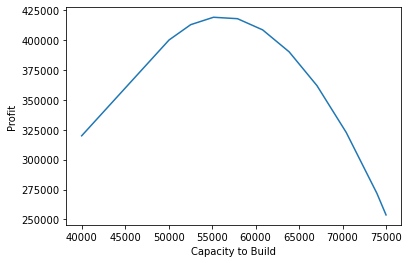

In [6]:
# Plot
r = [i for i in range(40000,75000,1)]
plt.plot(r, [-profit(j) for j in r])
#plt.plot([optimization.x[0],optimization.x[0]],[0,-1*profit(optimization.x[0])])
plt.xlabel('Capacity to Build')
plt.ylabel('Profit')
plt.show()

# EXECUTIVE SUMMARY:<br />
<font size="2">
    
-- The plant will be producing to capacity in each of years 3 through 10.<br />
$\hspace{2mm}$    -- A larger plant would represent greater sales, which gains are counterbalanced by the cost of building and maintaining capacity.

-- The optimal plant size can be estimated by constructing a data table giving 10-year profit as a function of plant capacity.<br />
$\hspace{2mm}$     -- Curve seems to peaks near 55,000 units of annual capacity.<br /> 
$\hspace{2mm}$     -- The search was refined to its optimal value of 55,125 by treating the problem as an unconstrained nonlinear program which maximizes a concave function that results from the sum of concave functions (following the composition rules seen in class).

-- The model makes a number of assumptions which may be unrealistic:<br />
$\hspace{2mm}$     -- Constant percentage growth rate in the demand for ten years (results in fractional numbers in some years).<br />
$\hspace{2mm}$     -- Taxes, aren't accounted for (what about depreciation of construction costs?).<br />
$\hspace{2mm}$     -- It assumes a 0% discount rate, so NPV calculations were not needed.<br />
$\hspace{2mm}$     -- 10-year time horizon is assumed (what about future business and/or the value of the plant?)

-- No storage is assumed, although not unreasonably, as pharmaceutical products could be perishable.<br />

(This solution builds on previous work by Dr. Scott Stevens)</font>
